In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["VECLIB_MAXIMUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

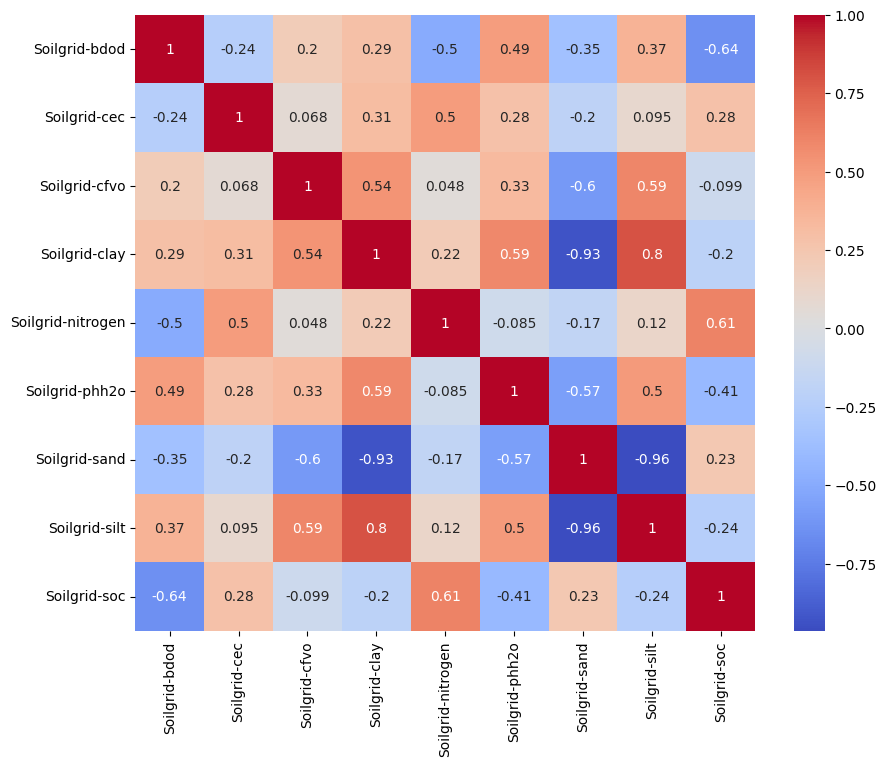

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/data/challenge2026MIASHS/EnvironmentalValues/SoilGrids/GLC25-PA-train-soilgrids.csv")
df = df.dropna()
df = df.drop(["surveyId", ], axis=1)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [6]:
df.var()

Soilgrid-bdod           90.275657
Soilgrid-cec          1913.016998
Soilgrid-cfvo         1653.038405
Soilgrid-clay         7020.291425
Soilgrid-nitrogen    10777.831775
Soilgrid-phh2o          33.565999
Soilgrid-sand        35729.619511
Soilgrid-silt        13238.459122
Soilgrid-soc         35350.285273
dtype: float64

In [3]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("surveyId", axis=1)
y = df["surveyId"]

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

KeyboardInterrupt: 

NameError: name 'train' is not defined